# RAF-DB Data Preprocessing Notebook

**Author:** Kareem Atout  
**Dataset:** RAF-DB (Real-world Affective Faces Database): Basic 7-class emotion recognition

## Overview

This notebook handles the preprocessing pipeline for the RAF-DB dataset, which will be used to train a CNN for facial emotion recognition. The dataset contains 7 basic emotions: Surprise, Fear, Disgust, Happiness, Sadness, Anger, and Neutral.

**The Data Preprocessing Notebook will**
1. Verify dataset structure and integrity
2. Analyze label distribution and class balance
3. Perform data cleaning and validation
4. Generate exploratory data analysis
5. Prepare images for CNN training (resize/normalize)
6. Create train/validation/test splits
7. Save metadata and summary statistics


## Dataset Information

- **Dataset:** RAF-DB Basic (7-class emotion recognition)
- **Location:** `data/rafdb/`
- **Structure:** Images organized in subdirectories by label (1-7), with CSV label files
- **Emotion Labels:**
  - 1: Surprise
  - 2: Fear
  - 3: Disgust
  - 4: Happiness
  - 5: Sadness
  - 6: Anger
  - 7: Neutral


## 1. Import Libraries and Setup


In [1]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

# Get the project root (parent of notebooks directory)
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
src_path = project_root / 'src'

# Add src directory to Python path
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Import RAF-DB dataset utilities
from data.rafdb_dataset import (
    load_rafdb_dataset,
    visualize_samples,
    EMOTION_LABELS,
    EMOTION_ORDER
)


## 2. Dataset Structure Verification


In [2]:
# Define paths
data_root = project_root / 'data' / 'rafdb'
output_dir = project_root / 'data' / 'rafdb_processed'
metadata_dir = project_root / 'data' / 'metadata'

# Create output directories
output_dir.mkdir(parents=True, exist_ok=True)
metadata_dir.mkdir(parents=True, exist_ok=True)

print("Dataset paths:")
print(f"  Source: {data_root}")
print(f"  Output: {output_dir}")
print(f"  Metadata: {metadata_dir}")
print()

# Verify dataset structure
print("Verifying dataset structure...")
print(f"  Train labels CSV exists: {(data_root / 'train_labels.csv').exists()}")
print(f"  Test labels CSV exists: {(data_root / 'test_labels.csv').exists()}")
print(f"  DATASET/train exists: {(data_root / 'DATASET' / 'train').exists()}")
print(f"  DATASET/test exists: {(data_root / 'DATASET' / 'test').exists()}")

# Check subdirectories
if (data_root / 'DATASET' / 'train').exists():
    train_dirs = sorted([d.name for d in (data_root / 'DATASET' / 'train').iterdir() if d.is_dir()])
    print(f"  Train label directories: {train_dirs}")

if (data_root / 'DATASET' / 'test').exists():
    test_dirs = sorted([d.name for d in (data_root / 'DATASET' / 'test').iterdir() if d.is_dir()])
    print(f"  Test label directories: {test_dirs}")


Dataset paths:
  Source: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\data\rafdb
  Output: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\data\rafdb_processed
  Metadata: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\data\metadata

Verifying dataset structure...
  Train labels CSV exists: True
  Test labels CSV exists: True
  DATASET/train exists: True
  DATASET/test exists: True
  Train label directories: ['1', '2', '3', '4', '5', '6', '7']
  Test label directories: ['1', '2', '3', '4', '5', '6', '7']


## 3. Load Dataset and Verify Integrity


In [3]:
# Load train and test datasets
print("Loading train dataset:")
train_images, train_labels = load_rafdb_dataset(str(data_root), split='train')
print(f"  Loaded {len(train_images)} train images")

print("\nLoading test dataset:")
test_images, test_labels = load_rafdb_dataset(str(data_root), split='test')
print(f"  Loaded {len(test_images)} test images")

print(f"\nTotal images: {len(train_images) + len(test_images)}")


Loading train dataset:
  Loaded 12271 train images

Loading test dataset:
  Loaded 3068 test images

Total images: 15339


In [4]:
# Verify image files exist and are readable
print("Validating image files:")
invalid_train = []
invalid_test = []

for img_path in train_images[:100]:  # Sample check
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception as e:
        invalid_train.append((img_path, str(e)))

for img_path in test_images[:100]:  # Sample check
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception as e:
        invalid_test.append((img_path, str(e)))

if invalid_train or invalid_test:
    print(f"  Warning: Found {len(invalid_train)} invalid train images (sampled)")
    print(f"  Warning: Found {len(invalid_test)} invalid test images (sampled)")
    if invalid_train:
        print(f"  Example: {invalid_train[0]}")
    if invalid_test:
        print(f"  Example: {invalid_test[0]}")
else:
    print("  All sampled images are valid!")


Validating image files:
  All sampled images are valid!


## 4. Label Distribution Analysis


In [5]:
# Count labels per class
train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

# Create summary DataFrame
summary_data = []
for label in range(1, 8):
    emotion_name = EMOTION_LABELS[label]
    summary_data.append({
        'Label': label,
        'Emotion': emotion_name,
        'Train_Count': train_counts.get(label, 0),
        'Test_Count': test_counts.get(label, 0),
        'Total_Count': train_counts.get(label, 0) + test_counts.get(label, 0)
    })

summary_df = pd.DataFrame(summary_data)
summary_df['Train_Percent'] = (summary_df['Train_Count'] / summary_df['Train_Count'].sum() * 100).round(2)
summary_df['Test_Percent'] = (summary_df['Test_Count'] / summary_df['Test_Count'].sum() * 100).round(2)

print("Label Distribution Summary:")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)
print(f"\nTotal train images: {summary_df['Train_Count'].sum()}")
print(f"Total test images: {summary_df['Test_Count'].sum()}")


Label Distribution Summary:
 Label   Emotion  Train_Count  Test_Count  Total_Count  Train_Percent  Test_Percent
     1  Surprise         1290         329         1619          10.51         10.72
     2      Fear          281          74          355           2.29          2.41
     3   Disgust          717         160          877           5.84          5.22
     4 Happiness         4772        1185         5957          38.89         38.62
     5   Sadness         1982         478         2460          16.15         15.58
     6     Anger          705         162          867           5.75          5.28
     7   Neutral         2524         680         3204          20.57         22.16

Total train images: 12271
Total test images: 3068


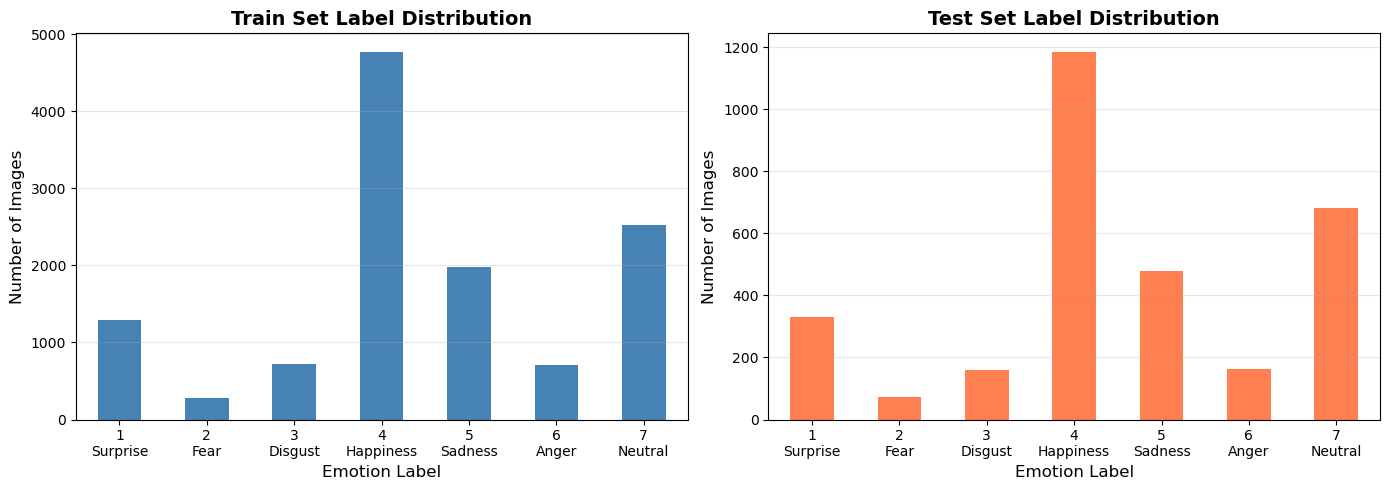

In [6]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train distribution
train_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Train Set Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion Label', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_xticklabels([f"{i}\n{EMOTION_LABELS[i]}" for i in range(1, 8)], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Test distribution
test_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Set Label Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Emotion Label', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_xticklabels([f"{i}\n{EMOTION_LABELS[i]}" for i in range(1, 8)], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(metadata_dir / 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Check for class imbalance
print("\nClass Balance Analysis:")
print("-" * 80)
train_total = summary_df['Train_Count'].sum()
test_total = summary_df['Test_Count'].sum()

for _, row in summary_df.iterrows():
    train_pct = row['Train_Percent']
    test_pct = row['Test_Percent']
    imbalance = abs(train_pct - test_pct)
    
    status = "✓ Balanced" if imbalance < 5 else "⚠ Imbalanced"
    print(f"{row['Emotion']:12s} | Train: {train_pct:5.2f}% | Test: {test_pct:5.2f}% | {status}")

# Overall balance check
max_train_pct = summary_df['Train_Percent'].max()
min_train_pct = summary_df['Train_Percent'].min()
train_imbalance_ratio = max_train_pct / min_train_pct if min_train_pct > 0 else float('inf')

print(f"\nTrain set imbalance ratio (max/min): {train_imbalance_ratio:.2f}")
if train_imbalance_ratio > 3:
    print("  ⚠ Warning: Significant class imbalance detected in training set")
else:
    print("  ✓ Training set is reasonably balanced")



Class Balance Analysis:
--------------------------------------------------------------------------------
Surprise     | Train: 10.51% | Test: 10.72% | ✓ Balanced
Fear         | Train:  2.29% | Test:  2.41% | ✓ Balanced
Disgust      | Train:  5.84% | Test:  5.22% | ✓ Balanced
Happiness    | Train: 38.89% | Test: 38.62% | ✓ Balanced
Sadness      | Train: 16.15% | Test: 15.58% | ✓ Balanced
Anger        | Train:  5.75% | Test:  5.28% | ✓ Balanced
Neutral      | Train: 20.57% | Test: 22.16% | ✓ Balanced

Train set imbalance ratio (max/min): 16.98
  ⚠ Warning: Significant class imbalance detected in training set


## 5. Exploratory Data Analysis


Sampling images from each emotion class:


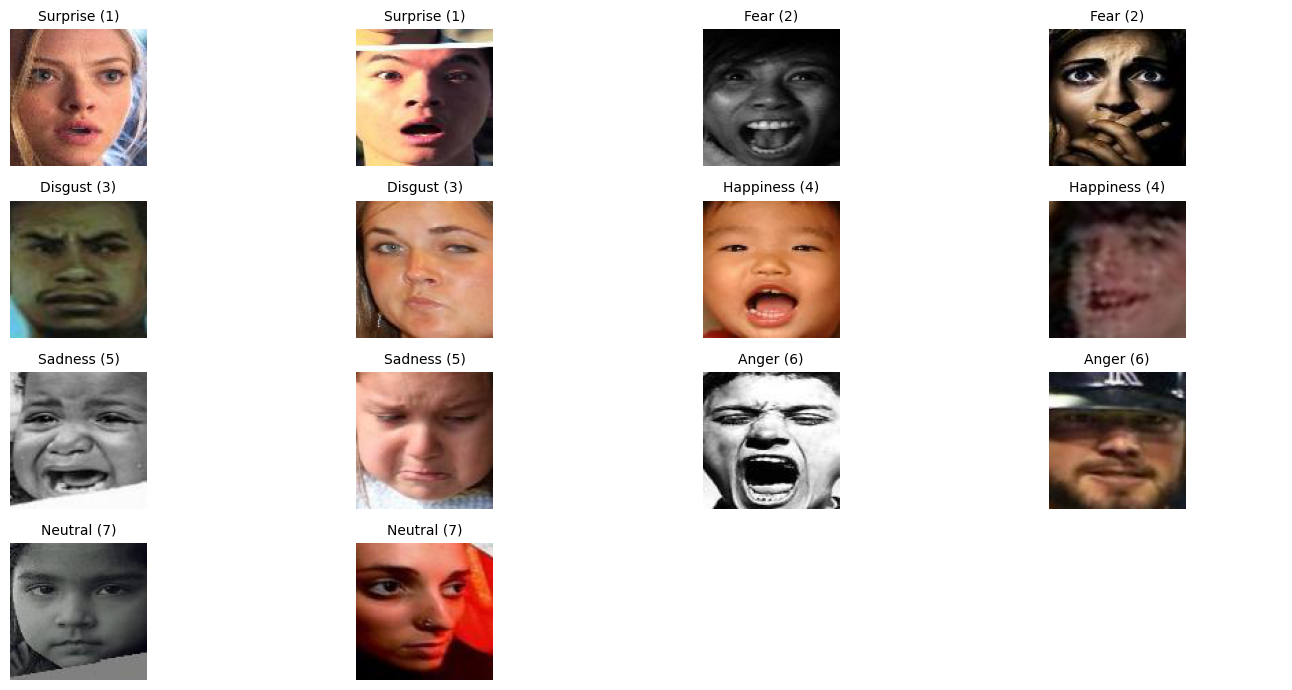

In [8]:
# Visualize sample images from each class
print("Sampling images from each emotion class:")


# Sample 2 images per class from train set
samples_per_class = 2
sample_images = []
sample_labels_list = []

for label in range(1, 8):
    # Get indices for this label
    label_indices = [i for i, l in enumerate(train_labels) if l == label]
    
    if len(label_indices) >= samples_per_class:
        # Randomly sample
        sampled_indices = np.random.choice(label_indices, samples_per_class, replace=False)
        for idx in sampled_indices:
            sample_images.append(train_images[idx])
            sample_labels_list.append(train_labels[idx])

# Visualize samples
visualize_samples(sample_images, sample_labels_list, num_samples=14, 
                 figsize=(14, 7), save_path=str(metadata_dir / 'sample_images.png'))


## 6. Create Train/Validation/Test Splits

The RAF-DB dataset comes with train and test splits. We'll create a validation set by splitting the training data (typically 80/20 or 90/10 split).


In [9]:
# Create validation split from training data (80/20 split)
# Use stratified sampling to maintain class distribution

from sklearn.model_selection import train_test_split

# Convert to numpy arrays for easier manipulation
train_images_arr = np.array(train_images)
train_labels_arr = np.array(train_labels)

# Stratified split: 80% train, 20% validation
train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
    train_images_arr,
    train_labels_arr,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_arr
)

print("Split Summary:")
print(f"Original train set: {len(train_images)} images")
print(f"  → New train set:  {len(train_imgs)} images ({len(train_imgs)/len(train_images)*100:.1f}%)")
print(f"  → Validation set: {len(val_imgs)} images ({len(val_imgs)/len(train_images)*100:.1f}%)")
print(f"Test set:           {len(test_images)} images")

# Verify stratification
print("\nValidation set class distribution:")
val_counts = pd.Series(val_lbls).value_counts().sort_index()
for label in range(1, 8):
    count = val_counts.get(label, 0)
    pct = count / len(val_lbls) * 100
    print(f"  {EMOTION_LABELS[label]:12s}: {count:4d} images ({pct:5.2f}%)")


Split Summary:
Original train set: 12271 images
  → New train set:  9816 images (80.0%)
  → Validation set: 2455 images (20.0%)
Test set:           3068 images

Validation set class distribution:
  Surprise    :  258 images (10.51%)
  Fear        :   56 images ( 2.28%)
  Disgust     :  143 images ( 5.82%)
  Happiness   :  955 images (38.90%)
  Sadness     :  397 images (16.17%)
  Anger       :  141 images ( 5.74%)
  Neutral     :  505 images (20.57%)


## 7. Image Preprocessing for CNN Training

We'll prepare images for CNN training by:
1. Resizing to a standard size (64×64)
2. Normalizing pixel values
3. Keeping RGB

In [10]:
# Define preprocessing parameters
TARGET_SIZE = (64, 64)  # Standard size for emotion recognition
RESIZE_MODE = 'RGB'  # Keep RGB channels

print(f"Preprocessing configuration:")
print(f"  Target size: {TARGET_SIZE}")
print(f"  Color mode: {RESIZE_MODE}")


Preprocessing configuration:
  Target size: (64, 64)
  Color mode: RGB


Testing preprocessing pipeline on sample images:


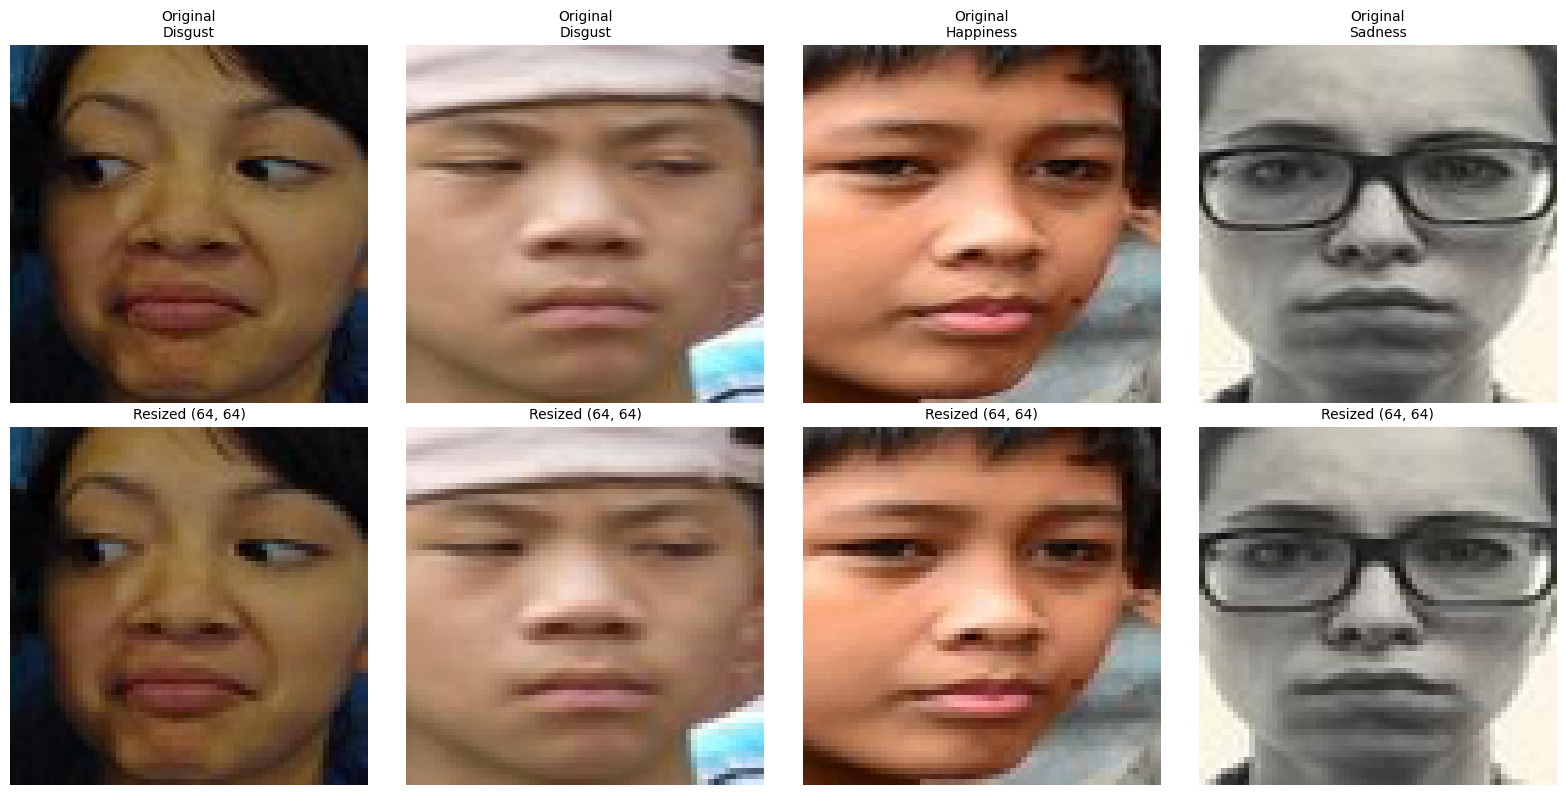

In [11]:
# Test preprocessing on a few sample images
print("Testing preprocessing pipeline on sample images:")

sample_indices = np.random.choice(len(train_imgs), 4, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, sample_idx in enumerate(sample_indices):
    img_path = train_imgs[sample_idx]
    label = train_lbls[sample_idx]
    
    # Original image
    img_orig = Image.open(img_path).convert('RGB')
    axes[0, idx].imshow(img_orig)
    axes[0, idx].set_title(f'Original\n{EMOTION_LABELS[label]}', fontsize=10)
    axes[0, idx].axis('off')
    
    # Resized image
    img_resized = img_orig.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
    axes[1, idx].imshow(img_resized)
    axes[1, idx].set_title(f'Resized {TARGET_SIZE}', fontsize=10)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig(metadata_dir / 'preprocessing_example.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save Metadata and Summary Files


In [12]:
# Create label mapping
# Map RAF-DB labels (1-7) to standard 0-indexed labels (0-6)
# Standard order: Anger, Disgust, Fear, Happiness, Sadness, Surprise, Neutral

# RAF-DB mapping: 1=Surprise, 2=Fear, 3=Disgust, 4=Happiness, 5=Sadness, 6=Anger, 7=Neutral
# Standard order: 0=Anger, 1=Disgust, 2=Fear, 3=Happiness, 4=Sadness, 5=Surprise, 6=Neutral

targets_map = {
    'emotion_to_label': {
        'Anger': 0,
        'Disgust': 1,
        'Fear': 2,
        'Happiness': 3,
        'Sadness': 4,
        'Surprise': 5,
        'Neutral': 6
    },
    'label_to_emotion': {
        0: 'Anger',
        1: 'Disgust',
        2: 'Fear',
        3: 'Happiness',
        4: 'Sadness',
        5: 'Surprise',
        6: 'Neutral'
    },
    'rafdb_to_standard': {
        1: 5,  # Surprise -> 5
        2: 2,  # Fear -> 2
        3: 1,  # Disgust -> 1
        4: 3,  # Happiness -> 3
        5: 4,  # Sadness -> 4
        6: 0,  # Anger -> 0
        7: 6   # Neutral -> 6
    },
    'rafdb_labels': EMOTION_LABELS
}

# Save targets map
with open(metadata_dir / 'targets_map_rafdb.json', 'w') as f:
    json.dump(targets_map, f, indent=2)
print(json.dumps(targets_map, indent=2))


{
  "emotion_to_label": {
    "Anger": 0,
    "Disgust": 1,
    "Fear": 2,
    "Happiness": 3,
    "Sadness": 4,
    "Surprise": 5,
    "Neutral": 6
  },
  "label_to_emotion": {
    "0": "Anger",
    "1": "Disgust",
    "2": "Fear",
    "3": "Happiness",
    "4": "Sadness",
    "5": "Surprise",
    "6": "Neutral"
  },
  "rafdb_to_standard": {
    "1": 5,
    "2": 2,
    "3": 1,
    "4": 3,
    "5": 4,
    "6": 0,
    "7": 6
  },
  "rafdb_labels": {
    "1": "Surprise",
    "2": "Fear",
    "3": "Disgust",
    "4": "Happiness",
    "5": "Sadness",
    "6": "Anger",
    "7": "Neutral"
  }
}


In [13]:
# Create split counts summary
split_counts = summary_df.copy()
split_counts['Val_Count'] = pd.Series(val_lbls).value_counts().sort_index().values
split_counts['Val_Percent'] = (split_counts['Val_Count'] / split_counts['Val_Count'].sum() * 100).round(2)

# Reorder columns
split_counts = split_counts[['Label', 'Emotion', 'Train_Count', 'Train_Percent', 
                             'Val_Count', 'Val_Percent', 'Test_Count', 'Test_Percent', 'Total_Count']]

# Save to CSV
split_counts.to_csv(metadata_dir / 'split_counts_rafdb.csv', index=False)

print("Split counts summary:")
print(split_counts.to_string(index=False))



Split counts summary:
 Label   Emotion  Train_Count  Train_Percent  Val_Count  Val_Percent  Test_Count  Test_Percent  Total_Count
     1  Surprise         1290          10.51        258        10.51         329         10.72         1619
     2      Fear          281           2.29         56         2.28          74          2.41          355
     3   Disgust          717           5.84        143         5.82         160          5.22          877
     4 Happiness         4772          38.89        955        38.90        1185         38.62         5957
     5   Sadness         1982          16.15        397        16.17         478         15.58         2460
     6     Anger          705           5.75        141         5.74         162          5.28          867
     7   Neutral         2524          20.57        505        20.57         680         22.16         3204


In [15]:
# Save dataset statistics
dataset_stats = {
    'dataset': 'RAF-DB',
    'total_images': len(train_images) + len(test_images),
    'train_images': len(train_imgs),
    'val_images': len(val_imgs),
    'test_images': len(test_images),
    'num_classes': 7,
    'emotions': list(EMOTION_LABELS.values()),
    'target_size': TARGET_SIZE,
    'color_mode': RESIZE_MODE,
    'train_val_split': '80/20',
    'preprocessing': {
        'resize': TARGET_SIZE,
        'normalization': 'To be applied during training',
        'augmentation': 'To be applied during training'
    }
}

with open(metadata_dir / 'dataset_stats_rafdb.json', 'w') as f:
    json.dump(dataset_stats, f, indent=2)

print(json.dumps(dataset_stats, indent=2))


{
  "dataset": "RAF-DB",
  "total_images": 15339,
  "train_images": 9816,
  "val_images": 2455,
  "test_images": 3068,
  "num_classes": 7,
  "emotions": [
    "Surprise",
    "Fear",
    "Disgust",
    "Happiness",
    "Sadness",
    "Anger",
    "Neutral"
  ],
  "target_size": [
    64,
    64
  ],
  "color_mode": "RGB",
  "train_val_split": "80/20",
  "preprocessing": {
    "resize": [
      64,
      64
    ],
    "normalization": "To be applied during training",
    "augmentation": "To be applied during training"
  }
}
